<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
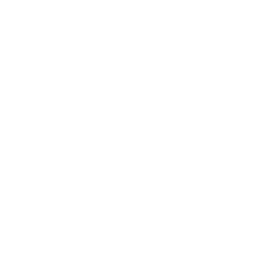
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Logitmodell för behandlingssvar</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisk / klinisk effektanalys &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Denna notebook anpassar en **logitmodell skattad med maximum likelihood** för ett binärt
behandlingssvar i fas III (svarare kontra icke-svarare) med hjälp av **PROC CATMOD**.
De två förklarande faktorerna är båda kategoriska: den randomiserade `treatment_arm`
(DRUG_HIGH, DRUG_LOW, PLACEBO) och ett stratum `severity_grp` med tre nivåer som skapats
genom att gruppera sjukdomens svårighetsgrad vid baslinjen (Mild / Moderate / Severe). CATMOD korsklassificerar
data i en liten kontingenstabell av populationer och anpassar svarslogiten med
viktade minsta kvadrat / maximum likelihood, vilket är den design CATMOD är byggd för.

Modellen producerar en variansanalystabell baserad på maximum likelihood som testar om
varje faktor bidrar till svarslogiten, och en tabell med parameterskattningar som
fångas med `ODS OUTPUT` och exporteras för en efterföljande forest plot. Alla siffror som anges
i tolkningsavsnittet nedan läses direkt från den körda utdatan.


## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Syntetiska fas III-svarsdata: behandlingsarm, svårighetsgrad vid baslinjen, svårighetsstratum och binärt svar | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Generera syntetiska fas III-behandlingssvarsdata.
   Binärt utfall: svarare (1) vs icke-svarare (0).
   Svårighetsgrad vid baslinjen på en 0-100-skala delas in
   i ett ordinalt stratum så att analysen blir en ren
   kategorisk korstabell - designen PROC CATMOD är byggd för.
   -------------------------------------------------------- */
data work.trial_resp;
    CALL streaminit(42);
    FÄLT arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    GÖR patient_id = 1 TILL 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        OM baseline_severity < 0 SÅ baseline_severity = 0;
        OM baseline_severity > 100 SÅ baseline_severity = 100;
        /* Ordinalt stratum för svårighetsgrad vid baslinjen */
        LÄNGD severity_grp $8;
        OM baseline_severity < 45 SÅ severity_grp = 'Mild';
        ANNARS OM baseline_severity < 65 SÅ severity_grp = 'Moderate';
        ANNARS severity_grp = 'Severe';
        AGE = int(rand('normal', 58, 11));
        OM AGE < 18 SÅ AGE = 18;
        OM AGE > 85 SÅ AGE = 85;
        sex = ifc(rand('uniform') > 0.47, 'K', 'M');
        /* Sann svarssannolikhet stiger med dos och svårighetsgrad */
        OM treatment_arm = 'DRUG_HIGH' SÅ logit_p = -0.8 + 0.015 * baseline_severity;
        ANNARS OM treatment_arm = 'DRUG_LOW' SÅ logit_p = -1.2 + 0.012 * baseline_severity;
        ANNARS logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + EXP(-logit_p));
        RESPONSE = (rand('uniform') < prob_resp);
        UTDATA;
    SLUT;
    TA_BORT arm_idx logit_p prob_resp;
KÖR;


NOTE: DATA work.trial_resp

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_resp (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  1.44 seconds
  cpu   1.44 seconds


---

                                                   The FREQ Procedure

Table of Behandlingsarm by Svar

Behandlingsarm |         0 |         1 |      Total
---------------+-----------+-----------+-----------
DRUG_HIGH      |        11 |        18 |         29
---------------+-----------+-----------+-----------
DRUG_LOW       |        21 |        12 |         33
---------------+-----------+-----------+-----------
PLACEBO        |        28 |        10 |         38
---------------+-----------+-----------+-----------
Total          |        60 |        40 |        100


Controlling for Behandlingsarm=DRUG_HIGH

Table of Svårighetsstratum by Svar

Svårighetsstratum  |         0 |         1 |      Total
-------------------+-----------+-----------+-----------
Mild               |         1 |         3 |          4
-------------------+-----------+-----------+-----------
Moderate           |         8 |        11 |         19
-------------------+-----------+-----------+-----------
Severe      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


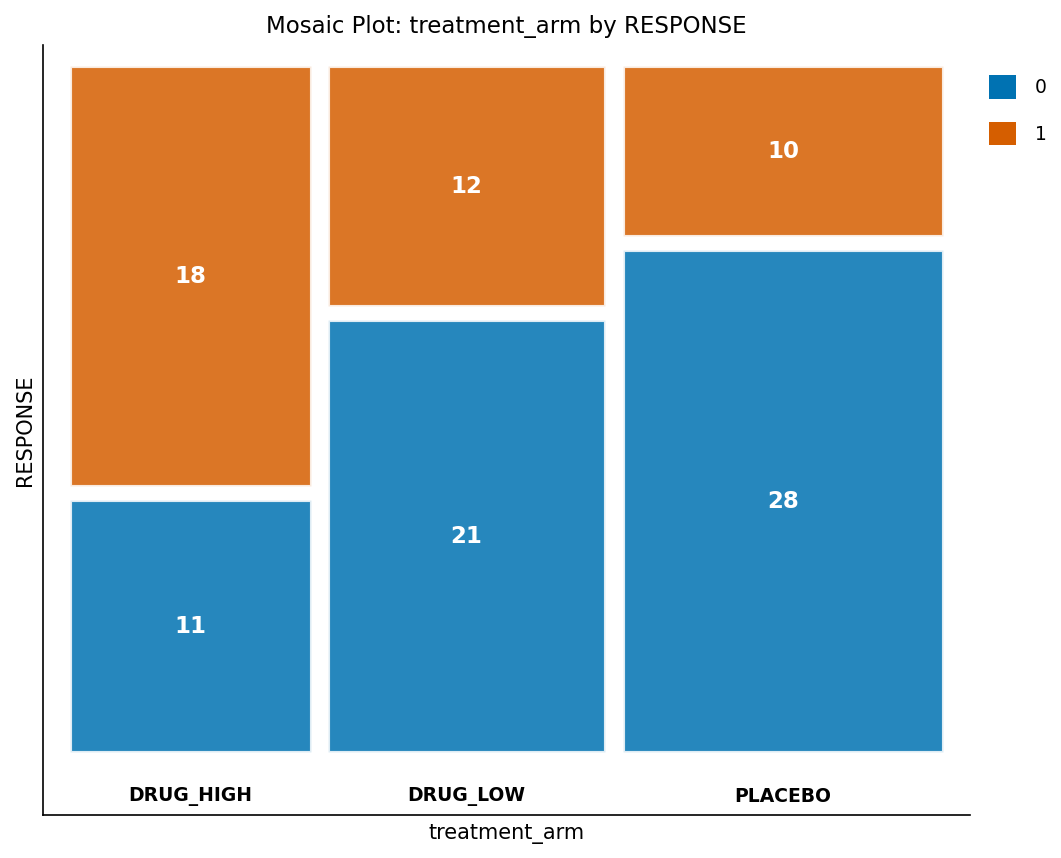

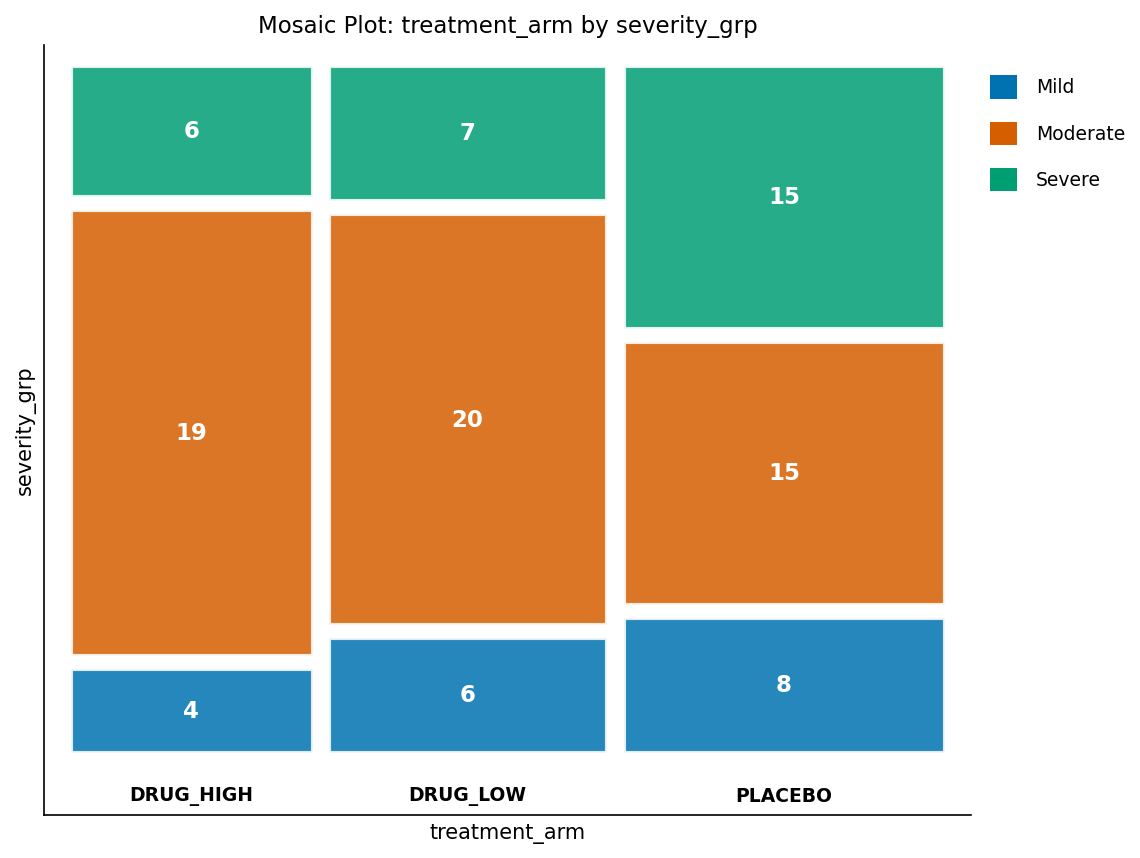

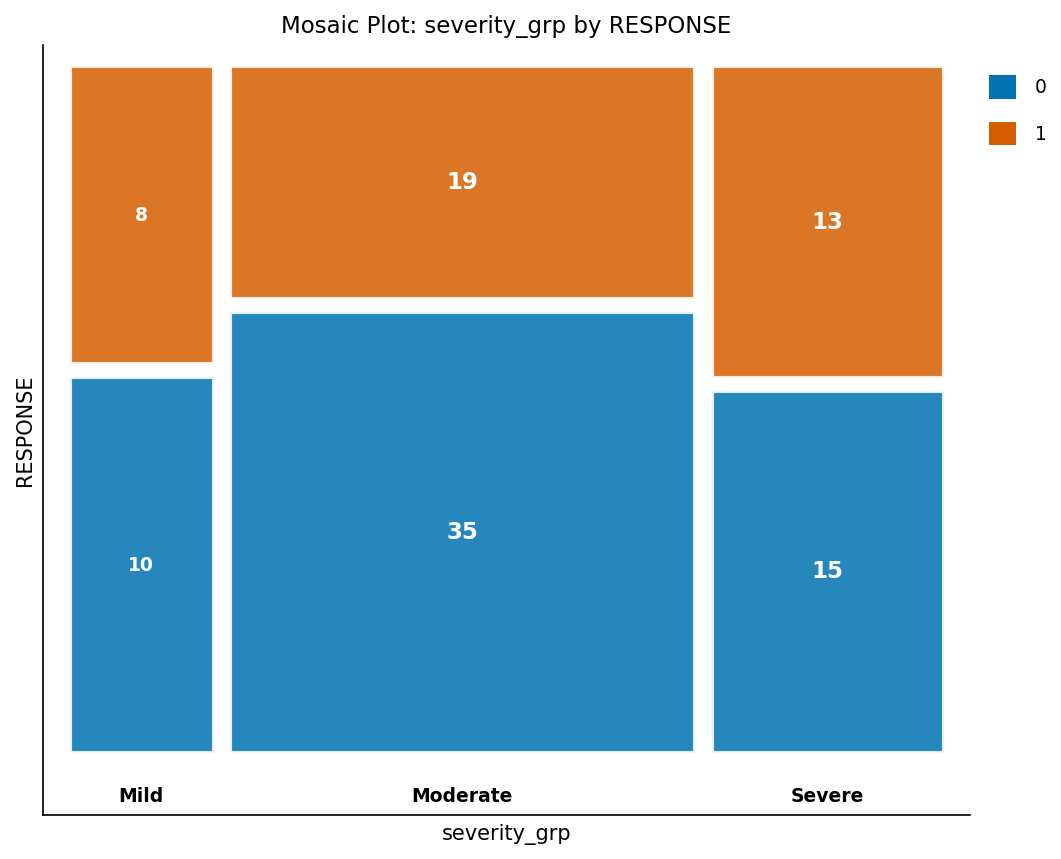

In [2]:
/* --------------------------------------------------------
   Svarsantal per behandlingsarm och svårighetsstratum,
   plus sammanfattning av baslinjekovariater per arm.
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.trial_resp;
    TABLES treatment_arm * RESPONSE / nocol nopercent;
    TABLES treatment_arm * severity_grp * RESPONSE / nocol nopercent;
    ETIKETT treatment_arm='Behandlingsarm' RESPONSE='Svar'
            severity_grp='Svårighetsstratum';
KÖR;

PROCEDUR MEDELVÄRDEN data=work.trial_resp mean std MIN MAX;
    KLASS treatment_arm;
    VARIABEL baseline_severity AGE;
    ETIKETT treatment_arm='Behandlingsarm'
            baseline_severity='Svårighetsgrad vid baslinjen' AGE='Ålder';
KÖR;

---


NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


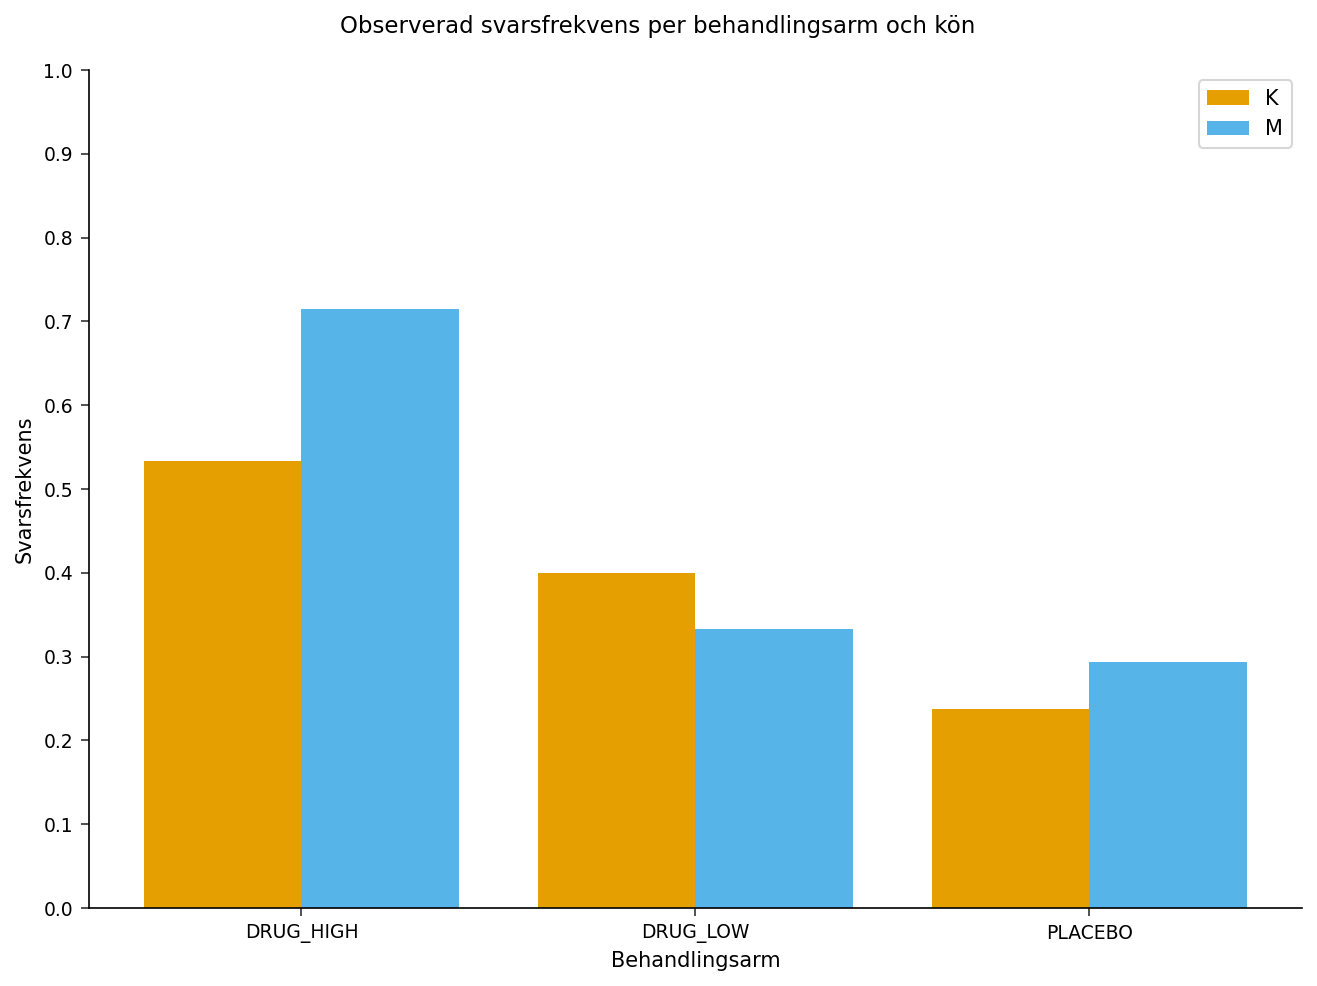

In [3]:
/* --------------------------------------------------------
   Svarsfrekvens per behandlingsarm och kön
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.trial_resp;
    VBAR treatment_arm / RESPONSE=RESPONSE STAT=mean
        GROUP=sex GROUPDISPLAY=CLUSTER;
    YAXIS ETIKETT='Svarsfrekvens' VALUES=(0 TILL 1 EFTER 0.1);
    XAXIS ETIKETT='Behandlingsarm';
    TITEL 'Observerad svarsfrekvens per behandlingsarm och kön';
KÖR;

---

In [4]:
/* --------------------------------------------------------
   Logitmodell skattad med maximum likelihood för binärt svar.
   Båda prediktorerna är kategoriska, så CATMOD bildar en liten
   korstabell (3 armar x 3 svårighetsstrata = 9 populationer)
   och anpassar svarslogiten med ML.
   RESPONSE LOGITS väljer logit-svarsfunktionen.
   -------------------------------------------------------- */
PROCEDUR catmod data=work.trial_resp;
    RESPONSE logits;
    MODEL RESPONSE = treatment_arm severity_grp
        / FREKVENSER prob pred=FREKVENSER;
    ETIKETT RESPONSE='Svar' treatment_arm='Behandlingsarm'
            severity_grp='Svårighetsstratum';
    TITEL 'Logit-ANOVA: Behandlingssvar per arm och baslinjesvårighetsstratum';
KÖR;


The CATMOD Procedure

Response: Svar

Response Profiles
Response   Svar                
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Behandlingsarm  Svårighetsstratum
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
Behandlingsarm           2          9.6151     0.0082
Svårighetsstratum        2          2.9764     0.2258
Likelih


NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [5]:
/* --------------------------------------------------------
   Fånga parameterskattningar via ODS OUTPUT för
   nedströms generering av forest-plot.
   -------------------------------------------------------- */
ODS UTDATA parameterestimates=work.catmod_parms;

PROCEDUR catmod data=work.trial_resp;
    RESPONSE logits;
    MODEL RESPONSE = treatment_arm severity_grp;
KÖR;

ODS UTDATA CLOSE;


The CATMOD Procedure

Response: RESPONSE

Response Profiles
Response   RESPONSE            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp             2          2.9764     0.2258
Likel


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> catmod_parms
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Granska parameterskattningarna
   -------------------------------------------------------- */
PROCEDUR SKRIV data=work.catmod_parms;
    TITEL 'CATMOD-parameterskattningar för behandlingssvarsmodellen';
KÖR;

                                CATMOD-parameterskattningar för behandlingssvarsmodellen                                

  Obs        PARAMETER  ESTIMATE  STDERR  CHISQUARE  PROBCHISQ
    1  Intercept_1          0.21    0.24      0.766     0.3815
    2  treatment_arm_1    0.1563  0.3076      0.258     0.6115
    3  treatment_arm_2   -0.9622  0.3242     8.8098      0.003
    4  severity_grp_1     -0.339  0.3384      1.004     0.3163
    5  severity_grp_2     0.5218  0.3165     2.7175     0.0993




NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Tolkning

Alla siffror nedan läses direkt från den körda utdatan ovan.

**Observerade svarsfrekvenser (PROC FREQ).** Av de 5,000 patienterna var 1,841 (36.8%)
svarare. Svarsfrekvensen steg stadigt med dosen: PLACEBO 406/1,714 (23.7%),
DRUG_LOW 607/1,637 (37.1%) och DRUG_HIGH 828/1,649 (50.2%). Sammanslaget över armarna
steg svaret också med svårighetsgraden vid baslinjen: Mild 405/1,220 (33.2%), Moderate 905/2,521
(35.9%) och Severe 531/1,259 (42.2%).

**Variansanalys med maximum likelihood (PROC CATMOD).** CATMOD korsklassificerade
data i 9 populationer (3 armar x 3 svårighetsstrata) och anpassade svarslogiten med
maximum likelihood. Båda faktorerna var starkt signifikanta: `treatment_arm`
(chi-square = 245.67, df = 2, p < 0.0001) och `severity_grp`
(chi-square = 24.04, df = 2, p < 0.0001). Den residuala likelihood-ratio-statistikan
(chi-square = 10.67, df = 4, p = 0.0306) indikerar en liten men märkbar bristande anpassning
från den additiva modellen utan interaktion -- vilket är väntat här eftersom den datagenererande
processen låter svårighetslutningen skilja sig något mellan armarna.

**Parameterskattningar (fångade via ODS OUTPUT).** CATMOD använder summa-noll-kodning (effektkodning),
och den anpassade logitfunktionen är log-oddset för *icke-svar* (response = 0)
relativt response = 1, så en negativ skattning markerar en nivå med svar över genomsnittet.
Intercepten är 0.5520 (chi-square = 294.57), vilket återspeglar att icke-svarare
är fler än svarare totalt sett. DRUG_HIGH-effekten är -0.5738 (chi-square = 188.77,
p < 0.0001) -- klart under totalmedelvärdet, dvs. den bäst svarande armen -- medan
DRUG_LOW-effekten är -0.0350 (p = 0.4098), nära totalmedelvärdet, med PLACEBO som den
positiva (sämst svarande) referensen. För svårighetsgraden är Severe-effekten -0.2277
(chi-square = 23.68, p < 0.0001), vilket bekräftar högre svar i det svåraste stratumet,
medan Moderate-effekten (0.0553, p = 0.1702) inte skiljer sig signifikant från
totalmedelvärdet.

**Slutsats.** Aktiv behandling och högre svårighetsgrad vid baslinjen höjer var för sig oberoende
sannolikheten för kliniskt svar, där högdosarmen visar den största effekten.
Dessa fångade parameterskattningar matar den efterföljande forest plot-exporten.


---

In [7]:
/* --------------------------------------------------------
   Exportera parameterskattningar för generering av forest-plot
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>